[1번] 27. Fraction and Reduce a Fraction  Create a class named Fraction having instance variables for numerator and denominator, and a method that reduces a faction to lowest terms by dividing the numerator and denominator by their greatest common divisor (GCD). The code for obtaining the GCD of two nonzero integers m and n is given below. Note: This class will be used here and in Exercises 29 as well.

In [60]:
class Fraction:
    def __init__(self, numerator, denominator): 
        self._numerator   = numerator
        self._denominator = denominator

    def GCD(m, n):  #Greatest Common Divisor
        while n != 0:
            t = n
            n = m % n
            m = t
        return m

    def reduce(self):
        gcd = Fraction.GCD(self._numerator, self._denominator)
        print(f"Reduction to lowest terms: {self._numerator//gcd}/{self._denominator//gcd}")


a = int(input("Enter numerator of fraction: "))
b = int(input("Enter denominator of fraction: "))

frac = Fraction(a,b)
frac.reduce()


Reduction to lowest terms: 2/5


[2번] 29. Convert a Decimal to a Fraction  Write a program that converts a decimal number to an equivalent fraction. A possible output is shown in the shaded box below. Use the class Fraction created in Exercise 27.

In [61]:
dec = input("Enter a positive decimal number less than 1: ")
exp = len(dec)-1
dec = int(dec.replace(".", ""))

frac2 = Fraction(dec, 10**exp)
frac2.reduce()


Reduction to lowest terms: 3/80


[3번] 11. Rock, Paper, Scissors  Write a program to play three matches of “rock, paper, scissors” between a person and a computer, and to print the game result. A possible output is shown in the shaded box below, where the last line should be changed to “TIE” in case of a tie. The program should use a class named Contestant, and its two subclasses named Human and Computer. After the person makes his or her choice, the computer should make its choice at random. The Contestant class should have instance variables for name and score.

In [62]:
import random

choices = ["rock", "paper", "scissors"]

enc = {
    "rock" : 0,
    "scissors": 1,
    "paper": 2,
}

compute = {
    (0,0): 0,
    (0,1): 1,
    (0,2): 2,
    (1,0): 2,
    (1,1): 0,
    (1,2): 1,
    (2,0): 1,
    (2,1): 2,
    (2,2): 0,
}


class Contestant:
    def __init__(self, name):
        self._name  = name
        self._score = 0
    
    def win(self):
        self._score += 1

    def getName(self):
        return self._name
    def getScore(self):
        return self._score

class Human(Contestant):
    def __init__(self, name):
        super().__init__(name)

    def choose(self):
        my = input(f"{self._name}, enter your choice: ")
        return my

class Computer(Contestant):
    def __init__(self, name):
        super().__init__(name)

    def choose(self):
        my = random.choice(choices)
        print(f"{self._name} chooses {my}")
        return my
    
me  = input("Enter name of human: ")
com = input("Enter name of computer: ")


me = Human(me)
com = Computer(com)

for match in range(3):
    me_c  = me.choose()
    com_c = com.choose()
    res   = compute[(enc[me_c], enc[com_c])]
    if res == 1:
        me.win()
    elif res == 2:
        com.win()
    print(f"{me.getName()}: {me.getScore()} {com.getName()}: {com.getScore()}") 

me_s  = me.getScore()
com_s = com.getScore()

if me_s > com_s:
    print(f"{me.getName()} WINS")
elif me_s < com_s:
    print(f"{com.getName()} WINS")
else:
    print("TIE")


Big Blue chooses scissors
Garry: 1 Big Blue: 0
Big Blue chooses paper
Garry: 2 Big Blue: 0
Big Blue chooses rock
Garry: 3 Big Blue: 0
Garry WINS


[4번] 1. United Nations  The file UN.txt gives data about the 193 members of the United Nations. Each line of the file contains four pieces of data about a country: name, continent, population (in millions), and land area (in square miles). Some lines of the file are ...  
Write a program that requests the name of a continent as input, and then displays the names (in descending order) of the five most densely populated U.N. member countries in that continent. A possible output is shown in the shaded box below. 

In [63]:
class Nation:
    def __init__(self, name, continent, population, land_area):
        self.name = name
        self.continent = continent
        self.population = population
        self.land_area = land_area

    def popDensity(self):
        return (self.population*(10**6))/self.land_area
    

nations = dict()

with open("UN.txt", 'r') as f:
    for line in f:
        datas = line.strip().split(",")
        if len(datas) == 4:
            nations[datas[0]] = Nation(datas[0], datas[1], float(datas[2]), float(datas[3]))

continent = input("Enter a continent: ")

matched = []
for nation in nations.values():
    if nation.continent == continent:
        matched.append(nation)

matched.sort(key=lambda nation: nation.popDensity(), reverse=True)

print(f"\t{matched[0].name}")
print(f"\t{matched[1].name}")
print(f"\t{matched[2].name}")
print(f"\t{matched[3].name}")
print(f"\t{matched[4].name}")


	Ecuador
	Colombia
	Venezuela
	Brazil
	Peru


[5번] XGBoost in action
Study [강의 08b] and train XGBoost for regeression. Then, do the followings:


In [64]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

train_data = pd.read_csv("./data/house_price_train.csv", index_col = 0)
test_data  = pd.read_csv("./data/house_price_test.csv", index_col = 0)

y_train_all = train_data["SalePrice"]
X_train_all = train_data.drop(["SalePrice"], axis = 1)
X_train_all = X_train_all.select_dtypes(include=[np.number])

# 8:1:1
num_total = len(y_train_all)
num_train = int(num_total * 0.8)
num_val   = int(num_total * 0.1)
num_test  = num_total - num_train - num_val

X_train = X_train_all[:num_train]
X_val = X_train_all[num_train:num_train+num_val]
X_test = X_train_all[num_train+num_val:]

y_train = y_train_all[:num_train]
y_val = y_train_all[num_train:num_train+num_val]
y_test = y_train_all[num_train+num_val:]

regressor1 = xgb.XGBRegressor()
regressor1.fit(X_train, y_train, eval_set = [(X_train, y_train), (X_val, y_val)], verbose=False)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
preds = regressor1.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 18223.6171875
RMSE: 26341.07241552629


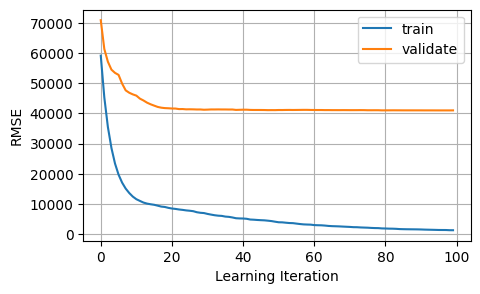

In [66]:
results1 = regressor1.evals_result()
train_rmse1 = results1['validation_0']['rmse']
val_rmse1 = results1['validation_1']['rmse']

plt.figure(figsize=(5, 3))
plt.plot(train_rmse1, label='train')
plt.plot(val_rmse1, label='validate')
plt.xlabel('Learning Iteration')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()
plt.show()

In [70]:
regressor2 = xgb.XGBRegressor(
    learning_rate=0.1, # 매개변수 변경
)

regressor2.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [71]:
preds2 = regressor2.predict(X_test)
mae2 = mean_absolute_error(y_test, preds2)
rmse2 = np.sqrt(mean_squared_error(y_test, preds2))

print(f"MAE: {mae2:.4f}")
print(f"RMSE: {rmse2:.4f}")

MAE: 17602.8633
RMSE: 27612.6105


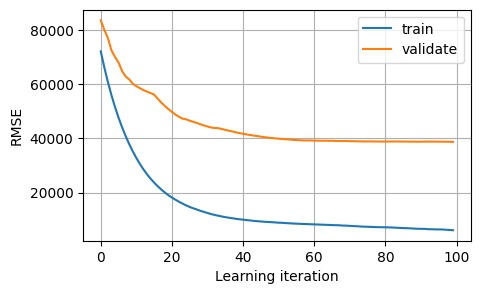

In [69]:
results2 = regressor2.evals_result()
train_rmse2 = results2['validation_0']['rmse']
val_rmse2 = results2['validation_1']['rmse']

plt.figure(figsize=(5, 3))
plt.plot(train_rmse2, label='train')
plt.plot(val_rmse2, label='validate')
plt.xlabel('Learning iteration')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()
plt.show()